### BRADLEY ROWLAND KIBWANA
### P15/144964/2022

# Business Intelligence - Data Preprocessing

## Business Question: Analyzing Customer Behavior and Sales Patterns

### Business Context:
As a supermarket chain, we need to understand our customers' behavior and sales patterns to optimize our operations and marketing strategies. This requires thorough data preprocessing to ensure our analysis is accurate and meaningful.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Read the data
df = pd.read_csv('supermarket_sales - Sheet1.csv')

# Display initial data
print("Original Data Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Original Data Shape: (1000, 17)

First few rows:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83       

## 1. Data Cleaning
### a) Handling Missing Data

In [2]:
# Check for missing values and fill if any exist
if 'Rating' in df.columns and df['Rating'].isnull().sum() > 0:
    df['Rating'].fillna(df['Rating'].mean(), inplace=True)  # Fill with mean

if 'Tax 5%' in df.columns and df['Tax 5%'].isnull().sum() > 0:
    df['Tax 5%'].fillna(0, inplace=True)  # Fill with 0 for tax

# Verify no missing values
print("After Handling Missing Data:")
print(df.isnull().sum())

After Handling Missing Data:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


### b) Handling Noisy Data - Binning

In [3]:
# Create bins for customer ratings (assuming Rating column exists)
if 'Rating' in df.columns:
    bins = [0, 2, 4, 6, 8, 10]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    df['Rating_Binned'] = pd.cut(df['Rating'], bins=bins, labels=labels, include_lowest=True)
    
    # Display distribution
    print("Rating Distribution:")
    print(df['Rating_Binned'].value_counts())
else:
    print("Rating column not found in the dataset")

Rating Distribution:
Rating_Binned
High         351
Medium       330
Very High    308
Low           11
Very Low       0
Name: count, dtype: int64


## 2. Data Transformation
### a) Normalization

In [4]:
# Identify numeric columns that exist in the dataset
potential_numeric_cols = ['Quantity', 'Unit price', 'Total', 'Tax 5%']
numeric_cols = [col for col in potential_numeric_cols if col in df.columns]

if numeric_cols:
    # Normalize numerical features
    scaler = MinMaxScaler()
    df_normalized = pd.DataFrame(scaler.fit_transform(df[numeric_cols]),
                                 columns=numeric_cols)
    
    # Display normalized data
    print("Normalized Data Sample:")
    print(df_normalized.head())
else:
    print("No matching numeric columns found for normalization")
    print("Available columns:", df.columns.tolist())

Normalized Data Sample:
   Quantity  Unit price     Total    Tax 5%
0  0.666667    0.718847  0.521616  0.521616
1  0.444444    0.057855  0.067387  0.067387
2  0.666667    0.403316  0.319628  0.319628
3  0.777778    0.535603  0.463549  0.463549
4  0.666667    0.848131  0.604377  0.604377


### b) Standardization

In [5]:
if numeric_cols:
    # Standardize numerical features
    scaler = StandardScaler()
    df_standardized = pd.DataFrame(scaler.fit_transform(df[numeric_cols]),
                                   columns=numeric_cols)
    
    # Display standardized data
    print("Standardized Data Sample:")
    print(df_standardized.head())
else:
    print("No numeric columns available for standardization")

Standardized Data Sample:
   Quantity  Unit price     Total    Tax 5%
0  0.509930    0.718160  0.919607  0.919607
1 -0.174540   -1.525303 -0.987730 -0.987730
2  0.509930   -0.352781  0.071446  0.071446
3  0.852165    0.096214  0.675780  0.675780
4  0.509930    1.156959  1.267125  1.267125


### c) Principal Component Analysis (PCA)

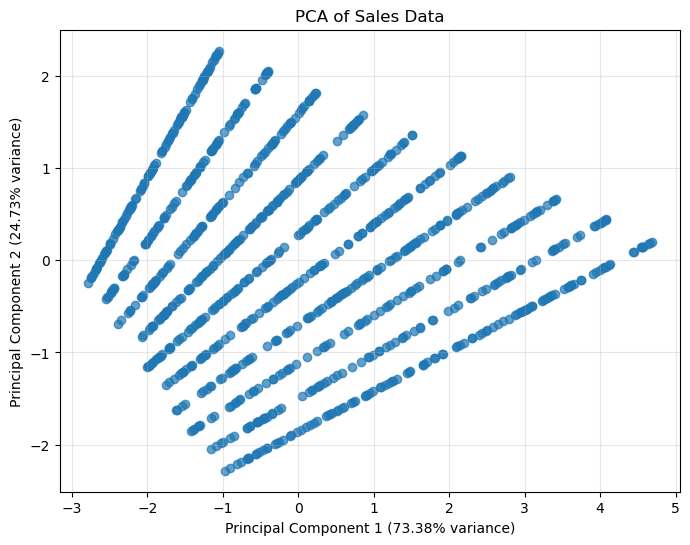

Total variance explained: 98.11%


In [ ]:
if numeric_cols and len(numeric_cols) >= 2:
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(df_standardized)
    
   
    df_pca = pd.DataFrame(data=pca_result,
                         columns=['PC1', 'PC2'])
    
    # Plotting PCA results
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.7)
    plt.title('PCA of Sales Data')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")
else:
    print("Need at least 2 numeric columns for PCA")

## 3. Data Reduction
### a) Feature Selection

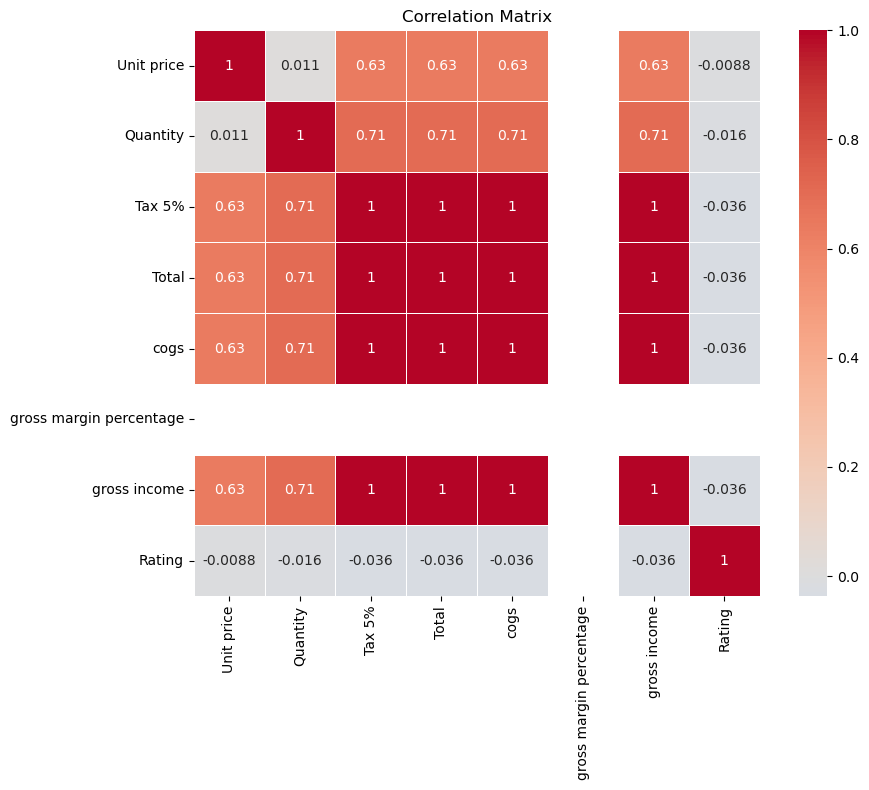

Features Correlated with Total Sales:
Total                      1.000000
Tax 5%                     1.000000
gross income               1.000000
cogs                       1.000000
Quantity                   0.705510
Unit price                 0.633962
Rating                     0.036442
gross margin percentage         NaN
Name: Total, dtype: float64


In [ ]:
# Calculate correlation matrix for numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    corr_matrix = numeric_df.corr()
    
    # Plot correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    # Select features with high correlation to target variable (if Total exists)
    if 'Total' in corr_matrix.columns:
        target_corr = corr_matrix['Total'].abs().sort_values(ascending=False)
        print("Features Correlated with Total Sales:")
        print(target_corr)
    else:
        print("Total column not found. Available numeric columns:")
        print(numeric_df.columns.tolist())
else:
    print("No numeric columns found for correlation analysis")

### b) Sampling

In [8]:
# Stratified sampling based on product line (if it exists)
if 'Product line' in df.columns:
    sample_size = min(100, len(df))  # Adjust sample size based on data size
    
    # Calculate fraction for sampling
    sample_fraction = sample_size / len(df)
    
    stratified_sample = df.groupby('Product line', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), max(1, int(len(x) * sample_fraction))), 
                          random_state=42)
    )
    
    print("Original Data Shape:", df.shape)
    print("Sampled Data Shape:", stratified_sample.shape)
    print("\nProduct Line Distribution in Sample:")
    print(stratified_sample['Product line'].value_counts())
else:
    print("Product line column not found. Available columns:")
    print(df.columns.tolist())

Original Data Shape: (1000, 18)
Sampled Data Shape: (98, 18)

Product Line Distribution in Sample:
Product line
Electronic accessories    17
Fashion accessories       17
Food and beverages        17
Home and lifestyle        16
Sports and travel         16
Health and beauty         15
Name: count, dtype: int64


/tmp/ipykernel_577202/1519867630.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('Product line', group_keys=False).apply(


### c) Aggregation

In [9]:
# Aggregate data by product line and month (if columns exist)
if 'Product line' in df.columns and 'Date' in df.columns:
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Month'] = df['Date'].dt.month
    
    # Define aggregation columns that exist
    agg_dict = {}
    if 'Total' in df.columns:
        agg_dict['Total'] = ['sum', 'mean']
    if 'Quantity' in df.columns:
        agg_dict['Quantity'] = ['sum', 'mean']
    if 'Unit price' in df.columns:
        agg_dict['Unit price'] = ['mean']
    
    if agg_dict:
        aggregated_data = df.groupby(['Product line', 'Month']).agg(agg_dict).reset_index()
        
        # Flatten multi-level columns
        aggregated_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) and col[1] != '' 
                                  else col[0] if isinstance(col, tuple) else col
                                  for col in aggregated_data.columns]
        
        print("Aggregated Data Sample:")
        print(aggregated_data.head())
        print("\nAggregated Data Shape:", aggregated_data.shape)
    else:
        print("No suitable columns found for aggregation")
else:
    print("Required columns (Product line, Date) not found for aggregation")
    print("Available columns:", df.columns.tolist())

Aggregated Data Sample:
             Product line  Month   Total_sum  Total_mean  Quantity_sum  \
0  Electronic accessories      1  18831.2880  348.727556           333   
1  Electronic accessories      2  17362.9050  321.535278           313   
2  Electronic accessories      3  18143.3385  292.634492           325   
3     Fashion accessories      1  19345.1160  302.267438           336   
4     Fashion accessories      2  19009.8615  316.831025           295   

   Quantity_mean  Unit price_mean  
0       6.166667        54.633519  
1       5.796296        54.424815  
2       5.241935        51.848710  
3       5.250000        55.369531  
4       4.916667        61.948167  

Aggregated Data Shape: (18, 7)
